# Neural Network For Handwritten Digit Recognition Using PyTorch

## Importing Essential Packages

In [155]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from PIL import Image


## Checking GPU compatibility

In [137]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Checking Dataset

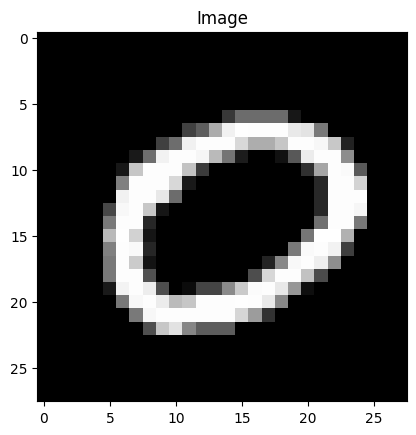

In [138]:
showImage = Image.open('../data/mnistmini/training/0/11654.png')

plt.title("Image")
plt.imshow(showImage, cmap = "gray")
plt.show()

## Loading and Transforming into Tensors

In [139]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels = 1),

    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees = 0, translate = (0.1, 0.1)),

    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

other_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels = 1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [140]:
train_data = datasets.ImageFolder(
    root = '../data/mnistmini/training',
    transform = train_transform
)

test_data = datasets.ImageFolder(
    root = "../data/mnistmini/testing",
    transform = other_transform
)

In [141]:
# adding validation data

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_subset, val_subset = random_split(train_data, [train_size, val_size])

In [142]:
train_loader = DataLoader(train_subset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_subset, batch_size = 64, shuffle = False)
test_loader = DataLoader(test_data, batch_size = 64, shuffle = False)

In [143]:
print("Classes:", train_data.classes)

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")
print(f"Test size: {len(test_data)}")

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train size: 800
Validation size: 200
Test size: 200


## Model Creation

In [144]:
class DigitModel(nn.Module):

    def __init__(self):
        super(DigitModel, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        x = self.fc4(x)

        return x


In [145]:
model = DigitModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [146]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 50

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        preds = model(images)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(preds, 1) # _ useless variable
        train_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = train_correct / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss = 0
    val_correct = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            preds = model(images)
            loss = criterion(preds, labels)

            val_loss += loss.item()

            _, predicted = torch.max(preds, 1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epochs: {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss = {val_loss:.4f}\n"
          f"Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}\n")

Epochs: 1, Train Loss: 2.2646, Val Loss = 2.1669
Train Accuracy: 0.1500, Val Accuracy: 0.2600

Epochs: 2, Train Loss: 2.0676, Val Loss = 2.0161
Train Accuracy: 0.3000, Val Accuracy: 0.3100

Epochs: 3, Train Loss: 1.8087, Val Loss = 1.8627
Train Accuracy: 0.4175, Val Accuracy: 0.3800

Epochs: 4, Train Loss: 1.5963, Val Loss = 1.6243
Train Accuracy: 0.4662, Val Accuracy: 0.4200

Epochs: 5, Train Loss: 1.5079, Val Loss = 1.4880
Train Accuracy: 0.4713, Val Accuracy: 0.4800

Epochs: 6, Train Loss: 1.4555, Val Loss = 1.6043
Train Accuracy: 0.5112, Val Accuracy: 0.4350

Epochs: 7, Train Loss: 1.3511, Val Loss = 1.3890
Train Accuracy: 0.5400, Val Accuracy: 0.5200

Epochs: 8, Train Loss: 1.2810, Val Loss = 1.6375
Train Accuracy: 0.5625, Val Accuracy: 0.4300

Epochs: 9, Train Loss: 1.3898, Val Loss = 1.5819
Train Accuracy: 0.5300, Val Accuracy: 0.5150

Epochs: 10, Train Loss: 1.2310, Val Loss = 1.3316
Train Accuracy: 0.5787, Val Accuracy: 0.5250

Epochs: 11, Train Loss: 1.1653, Val Loss = 1.2790

## Model Evaluation

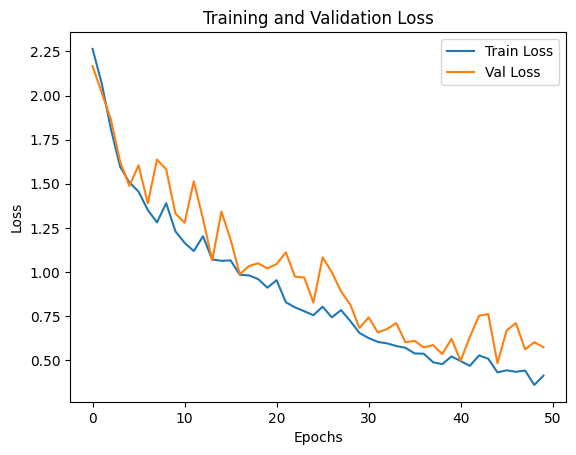

In [150]:
plt.title("Training and Validation Loss")

plt.plot(train_losses, label = "Train Loss")
plt.plot(val_losses, label = "Val Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

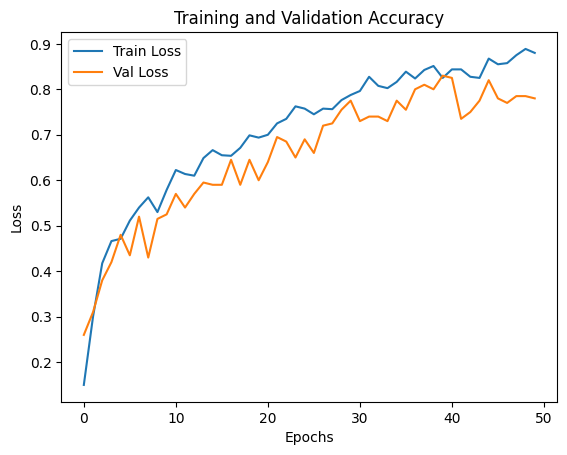

In [151]:
plt.title("Training and Validation Accuracy")

plt.plot(train_accuracies, label = "Train Loss")
plt.plot(val_accuracies, label = "Val Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [153]:
test_correct = 0
total = 0

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss = 0

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / len(test_loader)
test_acc = test_correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.1206
Test Accuracy: 0.8500


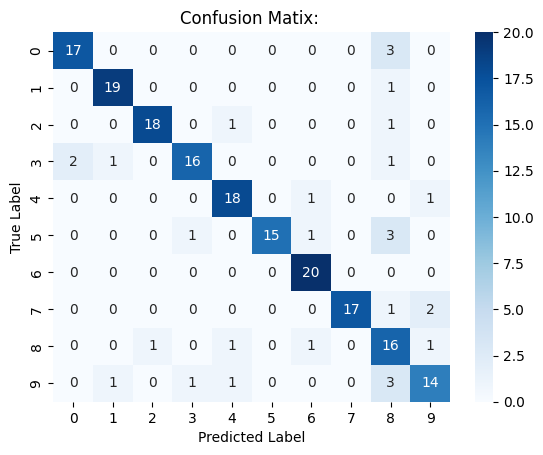

In [156]:
cm = confusion_matrix(all_labels, all_preds)

plt.title('Confusion Matix: ')

sns.heatmap(cm, annot = True, cmap = "Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [157]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.90      0.95      0.93        20
           2       0.95      0.90      0.92        20
           3       0.89      0.80      0.84        20
           4       0.86      0.90      0.88        20
           5       1.00      0.75      0.86        20
           6       0.87      1.00      0.93        20
           7       1.00      0.85      0.92        20
           8       0.55      0.80      0.65        20
           9       0.78      0.70      0.74        20

    accuracy                           0.85       200
   macro avg       0.87      0.85      0.85       200
weighted avg       0.87      0.85      0.85       200



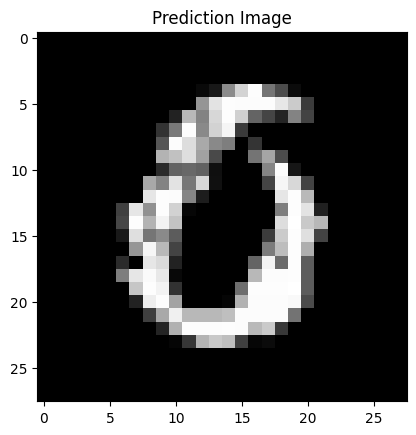

Actual: 0, Predicted: 0


In [165]:
predImage = Image.open('../data/mnistmini/testing/0/1438.png')

plt.title("Prediction Image")
plt.imshow(predImage, cmap = "gray")
plt.show()

model.eval()

with torch.no_grad():
    image_tensor = other_transform(predImage)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    output = model(image_tensor)
    _, predicted = torch.max(output, 1)

print(f"Actual: 0, Predicted: {predicted.item()}")

## Saving the Model

In [166]:
torch.save(model.state_dict(), "../models/digit_pytorch_model.pth")

## Inferencing With New Digits

In [185]:
inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels = 1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [202]:
model = DigitModel().to(device)
model.load_state_dict(torch.load('../models/digit_pytorch_model.pth', map_location = device))

model.eval()

def predict_digit(image_path):
    image = Image.open(image_path)

    plt.title("Actual Digit")

    plt.imshow(image, cmap = 'gray')
    plt.axis("off")
    plt.show()

    image_tensor = inference_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

    print(f"Predicted Digit: {predicted.item()}")


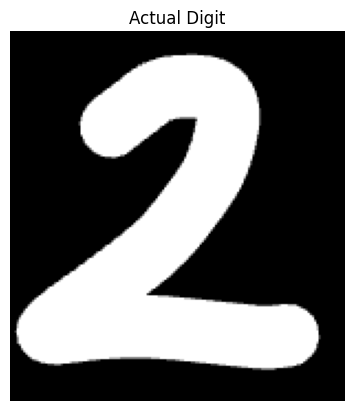

Predicted Digit: 2


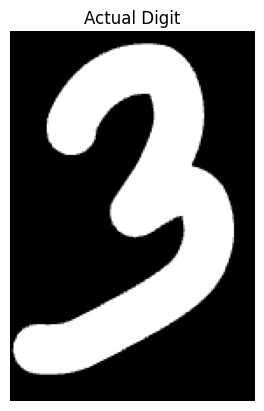

Predicted Digit: 3


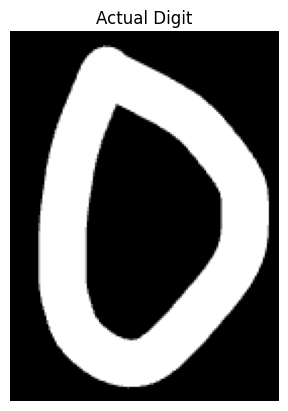

Predicted Digit: 0


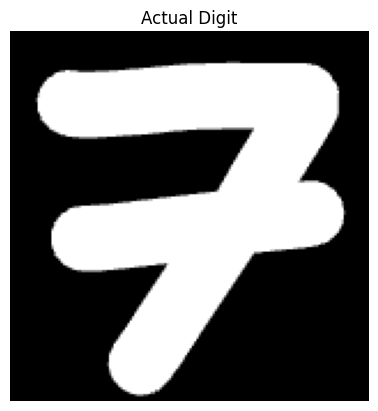

Predicted Digit: 2


In [203]:
predict_digit('../data/mnistmini/extra/Two.png')
predict_digit('../data/mnistmini/extra/Three.png')
predict_digit('../data/mnistmini/extra/Zero.png')
predict_digit('../data/mnistmini/extra/Seven.png')